In [1]:
# Notebook that reads a metric and exports it
# as a formatted disturbance product including
# generation of a browse image. 

In [2]:
import numpy as np
from pathlib import Path
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

In [3]:
DATA_PATH = Path('out/los-angeles-fire/merge_test')
METRIC_PATH = DATA_PATH / 'merged_eroded_transformer_avg_weighted.tif'

In [4]:
# general metric information (should be extracted from paths)
METRIC_NAME = 'transformer' #['transformer', 'cusum_prob_max'...]
TRACK_NUMBER = 'T064'

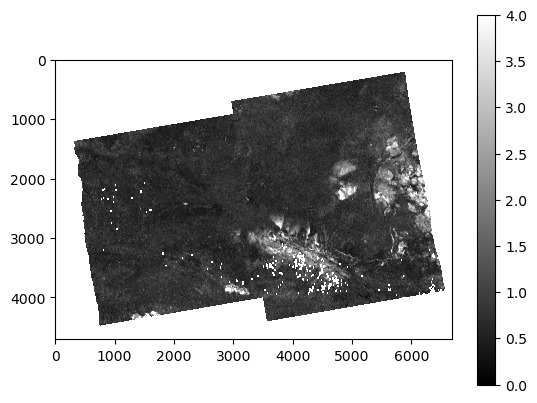

In [5]:
# Load and preview the metric
with rasterio.open(METRIC_PATH) as src:
    metric = src.read(1)
    metric_p = src.profile

# plot the data
plt.imshow(metric, vmin=0, vmax=4, cmap='gray')
plt.colorbar()
plt.show()


In [6]:
# get transform, height and width
print('transform =', metric_p['transform'])
print('height, width =', metric.shape[-2:])

transform = | 30.00, 0.00, 307350.00|
| 0.00,-30.00, 3900750.00|
| 0.00, 0.00, 1.00|
height, width = (4707, 6685)


In [7]:
# Define output directory for the disturbance product
dist_out_path = DATA_PATH / f'dist_{METRIC_NAME}_track_{TRACK_NUMBER}_test.tiff'

In [8]:
# create array for disturbance product
dist_arr = np.zeros(metric.shape[-2:], dtype=np.uint8)
# get nan mask
nan_mask = np.isnan(metric)
# set nan values to 255
dist_arr[nan_mask] = 255


In [9]:
# Establish thresholds for the metric types
if METRIC_NAME == 'transformer':
    aggressive_range = (metric >=2.5)
    dist_arr[aggressive_range] = 1
    conservative_range = (metric >=4.5)
    dist_arr[conservative_range] = 4
elif METRIC_NAME == 'cusum_prob_max':
    aggressive_range = (metric >=.9)
    dist_arr[aggressive_range] = 1
    conservative_range = (metric >=.95)
    dist_arr[conservative_range] = 4

In [10]:
# define colormap
colormap = {
    0: (18, 18, 18, 255),       # No disturbance
    1: (0, 85, 85, 255),        # First low
    2: (137, 127, 78, 255),     # Provisional low
    3: (222, 224, 67, 255),     # Confrimed low
    4: (0, 136, 136, 255),      # First high
    5: (228, 135, 39, 255),     # Provisional high
    6: (224, 27, 7, 255),       # Confirmed high
    7: (119, 119, 119, 255),    # Confirmed low finished
    8: (221, 221, 221, 255),    # Confirmed high finished
    9: (0, 0, 0, 255)           # No data
}

In [11]:
# Update the profile to save the disturbance product
p_dist = metric_p.copy()
p_dist['dtype'] = 'uint8'
p_dist['nodata'] = 255

# save to file
with rasterio.open(dist_out_path, 'w', **p_dist) as ds:
    ds.write(dist_arr, 1)
    ds.write_colormap(1, colormap)

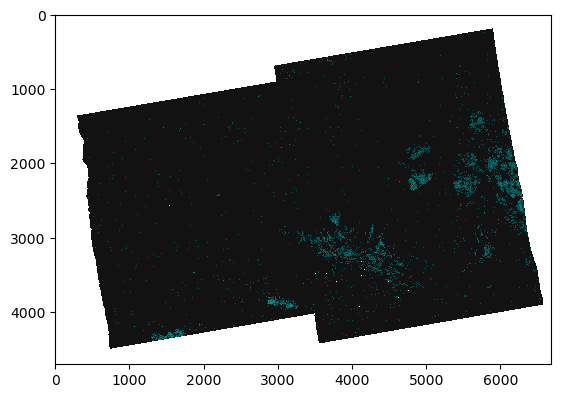

In [12]:
# Preview
# cmap = ListedColormap([colormap.get(key, (1, 1, 1, 1)) for key in range(256)])
cmap = ListedColormap([np.array(colormap.get(key, (255, 255, 255, 255))) / 255 for key in range(256)])
plt.imshow(dist_arr, cmap=cmap, interpolation='none')

In [ ]:
# As a function
def generate_disturbance_map(metric, metric_p, dist_out_path, metric_name):
    """
    Generate a disturbance map formatted output.
    Parameters:
        metric (numpy.ndarray): Input metric array (assumed to be 3D: bands x height x width).
        dist_out_path: Path to save the output raster.
        metric_p: Raster profile for saving the output.
        metric_name: Name of the metric type ('transformer','cusum_prob_max'...etc).

    """
    # Create array for disturbance product
    dist_arr = np.zeros(metric.shape[-2:], dtype=np.uint8)

    # Get nan mask (ensure it's 2D)
    nan_mask = np.isnan(metric[0, :, :])
    dist_arr[nan_mask] = 255  # Set NaN values to 255 (nodata)

    # Establish thresholds for metric types
    if metric_name == 'transformer':
        aggressive_range = (metric[0, :, :] >= 2.5)
        dist_arr[aggressive_range] = 1
        conservative_range = (metric[0, :, :] >= 4.5)
        dist_arr[conservative_range] = 4
    elif metric_name == 'cusum_prob_max':
        aggressive_range = (metric[0, :, :] >= 0.9)
        dist_arr[aggressive_range] = 1
        conservative_range = (metric[0, :, :] >= 0.95)
        dist_arr[conservative_range] = 4

    # Define colormap (0-255 integer values)
    colormap = {
        0: (18, 18, 18, 255),       # No disturbance
        1: (0, 85, 85, 255),        # First low
        2: (137, 127, 78, 255),     # Provisional low
        3: (222, 224, 67, 255),     # Confrimed low
        4: (0, 136, 136, 255),      # First high
        5: (228, 135, 39, 255),     # Provisional high
        6: (224, 27, 7, 255),       # Confirmed high
        7: (119, 119, 119, 255),    # Confirmed low finished
        8: (221, 221, 221, 255),    # Confirmed high finished
        9: (0, 0, 0, 255)           # No data
    }

    # Update the profile 
    p_dist = metric_p.copy()
    p_dist['dtype'] = 'uint8'
    p_dist['nodata'] = 255  # Set nodata 

    # Save to file
    with rasterio.open(dist_out_path, 'w', **p_dist) as ds:
        ds.write(dist_arr, 1)  # Write the disturbance array
        ds.write_colormap(1, colormap)  # Apply the corrected colormap

    print(f"Disturbance map saved to {dist_out_path}")